<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt



In [32]:
cols = ['project', 'commit', 'author', 'time', 'message']
raw = pd.read_csv('wch356_project_summary.csv', sep=';', header=None, names=cols)

# keep one copy of each commit, then relabel from the correct project list
raw = raw.drop(columns='project').drop_duplicates(subset='commit')
commits = pd.read_csv('df_commits.csv', index_col=0)
clean = (raw.merge(commits, left_on='commit', right_on='sha1')
            .drop(columns='sha1')[cols]
            .drop_duplicates())

clean.to_csv('wch356_project_summary.csv', sep=';', index=False, header=False, mode='w')
print(clean['project'].value_counts())

project
fedml-ai_fedml                     22540
alicevision_meshroom                7062
knausb_vcfr                         1539
fmidev_smartmet-library-newbase     1360
kristofferc_pgfplotsx.jl            1145
fizban007_coffeegpu                  688
latte-central_latte                  488
dkazanc_tomophantom                  441
stineb_mct                           377
clayne_retrowrite                    373
Name: count, dtype: int64


In [33]:
df = pd.read_csv("wch356_project_summary.csv", sep=";", header=None)
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,kristofferc_pgfplotsx.jl,00103d05f1291a1acf567cbd3f18cb60355096de,autodocs <autodocs>,1528883833,build based on 07d0d25\r\n,2018-06
1,kristofferc_pgfplotsx.jl,00205d9769d1eebf71c061df26c48c30badfbd8a,Kristoffer Carlsson <kcarlsson89@gmail.com>,1534505613,fixes for the display system\r\n,2018-08
2,kristofferc_pgfplotsx.jl,007c35740b47d823f6c8604ceecdf630f2e5f40a,Documenter.jl <documenter@juliadocs.github.io>,1707723004,build based on 3e224d5\r\n,2024-02
3,kristofferc_pgfplotsx.jl,0126d3f46b1b77542c56121a29150387327f4648,Kristoffer Carlsson <kcarlsson89@gmail.com>,1521891456,add ... example in options section\r\n,2018-03
4,kristofferc_pgfplotsx.jl,01c54eda7d7fbfa1f80a50f109d20e1d0853573e,Jerome Guterl <guterlj@fusion.gat.com>,1707746651,Merge c754a315c5f6fe884f98e969a6736d7b087871a6...,2024-02


In [34]:
prj='stineb_mct'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
monthly_counts[['Month','Commits']].rename(columns={'Commits':'#Commits'}).to_csv('wch356_commits_timeseries_'+prj+'.csv', sep=';', index=False)


In [35]:
print(len(df1))
print(df['project'].unique())

377
<StringArray>
[       'kristofferc_pgfplotsx.jl',             'fizban007_coffeegpu',
               'clayne_retrowrite',             'dkazanc_tomophantom',
            'alicevision_meshroom', 'fmidev_smartmet-library-newbase',
                     'knausb_vcfr',                  'fedml-ai_fedml',
             'latte-central_latte',                      'stineb_mct']
Length: 10, dtype: str


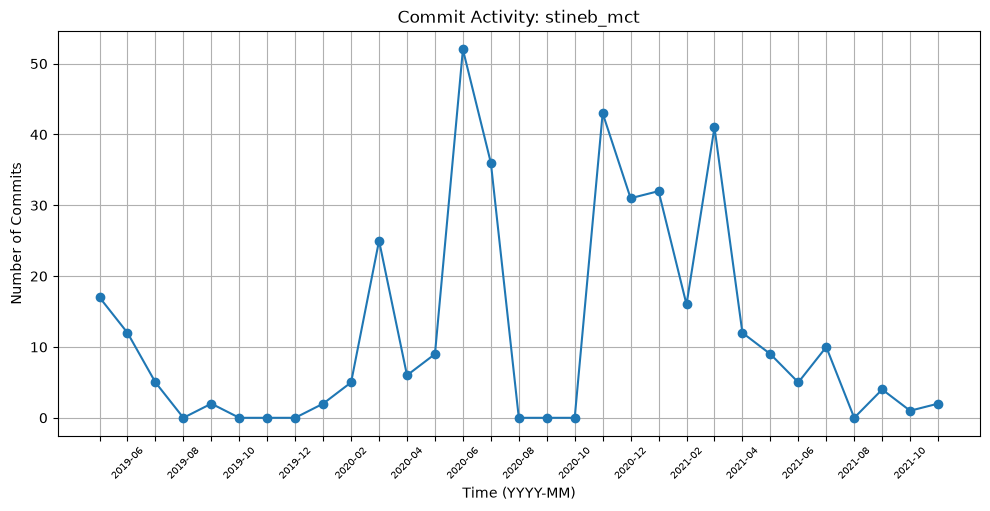

In [36]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("wch356_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

In [37]:
projects = ['kristofferc_pgfplotsx.jl', 'fizban007_coffeegpu', 'clayne_retrowrite',
            'dkazanc_tomophantom', 'alicevision_meshroom', 'fmidev_smartmet-library-newbase',
            'knausb_vcfr', 'fedml-ai_fedml', 'latte-central_latte', 'stineb_mct']

# Fill in from GitHub: [stars, forks, last commit date]
github = {p: [None, None, None] for p in projects}
# github['stineb_mct'] = [12, 3, '2024-02-18']   <- example format
github['kristofferc_pgfplotsx.jl']        = [312, 37, '2025-10-06']
github['fizban007_coffeegpu']             = [10, 6, '2025-02-20']
github['clayne_retrowrite']               = [0, 0, '2025-04-26']
github['dkazanc_tomophantom']             = [135, 57, '2026-09-14']
github['alicevision_meshroom']            = [13000, 1200, '2026-10-06']
github['fmidev_smartmet-library-newbase'] = [0, 1, '2026-10-04']
github['knausb_vcfr']                     = [270, 54, '2026-06-08']
github['fedml-ai_fedml']                  = [4100, 766, '2024-05-13']
github['latte-central_latte']             = [270, 14, '2026-05-29']
github['stineb_mct']                      = [6, 3, '2026-09-01']


# Fill in after looking at your charts: steady, rising, declining, U-shaped, cyclical, irregular
pattern = {p: None for p in projects}
pattern['dkazanc_tomophantom'] = 'declining'
pattern['fedml-ai_fedml'] = 'irregular'
pattern['fizban007_coffeegpu'] = 'irregular'
pattern['fmidev_smartmet-library-newbase'] = 'declining'
pattern['knausb_vcfr'] = 'irregular'
pattern['kristofferc_pgfplotsx.jl'] = 'declining'
pattern['latte-central_latte'] = 'cyclical'
pattern['stineb_mct'] = 'irregular'
pattern['alicevision_meshroom'] = 'rising'
pattern['clayne_retrowrite'] = 'cyclical'

stats = []
for prj in projects:
    ts = pd.read_csv('wch356_commits_timeseries_'+prj+'.csv', sep=';')
    g = df[df['project']==prj]
    vals = ts['#Commits'].tolist()

    # find every stretch of zero-commit months
    runs, i = [], 0
    while i < len(vals):
        if vals[i] == 0:
            j = i
            while j < len(vals) and vals[j] == 0:
                j += 1
            runs.append((i, j - i))
            i = j
        else:
            i += 1

    if runs:
        s, length = max(runs, key=lambda r: r[1])
        gap_start, gap_end = ts['Month'][s], ts['Month'][s+length-1]
        after = int(sum(vals[s+length:]))
    else:
        gap_start, gap_end, length, after = None, None, 0, int(sum(vals))

    times = pd.to_datetime(g['time'], unit='s')
    stats.append({
        'project': prj,
        'number of commits': g['commit'].nunique(),
        'number of authors': g['author'].nunique(),
        'max time': times.max().strftime('%Y-%m-%d'),
        'min time': times.min().strftime('%Y-%m-%d'),
        'number of stars': github[prj][0],
        'number of forks': github[prj][1],
        'last commit date': github[prj][2],
        'LongestGapStart': gap_start,
        'LongestGapEnd': gap_end,
        'LongestGapLength': length,
        'NumCommitsAfterLastGap': after,
        'NumberOfGapsInTimeline': sum(1 for _, l in runs if l >= 3),
        'ActivityPattern': pattern[prj],
    })

stats = pd.DataFrame(stats)
stats.to_csv('wch356_project_stats.csv', index=False)
stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,kristofferc_pgfplotsx.jl,1145,63,2025-10-06,2017-05-05,312,37,2025-10-06,2025-05,2025-09,5,19,5,declining
1,fizban007_coffeegpu,688,14,2025-02-20,2019-06-07,10,6,2025-02-20,2024-02,2025-01,12,1,4,irregular
2,clayne_retrowrite,373,15,2025-04-26,2018-08-29,0,0,2025-04-26,2024-06,2025-03,10,3,4,cyclical
3,dkazanc_tomophantom,441,19,2025-04-02,2017-07-01,135,57,2026-09-14,2022-11,2023-08,10,33,4,declining
4,alicevision_meshroom,7062,142,2025-11-04,2015-06-13,13000,1200,2026-10-06,2017-01,2017-02,2,6661,0,rising
5,fmidev_smartmet-library-newbase,1360,29,2025-10-28,2016-12-01,0,1,2026-10-04,2025-04,2025-05,2,7,0,declining
6,knausb_vcfr,1539,26,2026-02-23,2013-10-28,270,54,2026-06-08,2020-11,2021-07,9,71,8,irregular
7,fedml-ai_fedml,22540,187,2025-10-28,2020-07-22,4100,766,2024-05-13,2022-01,2022-02,2,20744,0,irregular
8,latte-central_latte,488,16,2025-03-13,2015-03-04,270,14,2026-05-29,2021-02,2022-10,21,27,9,cyclical
9,stineb_mct,377,8,2021-11-08,2019-05-01,6,3,2026-09-01,2019-10,2019-12,3,341,2,irregular


# Part 3




In [38]:
rows = []
for _, r in stats.iterrows():
    prj = r['project']
    if pd.isna(r['LongestGapStart']):   # no gap in this project
        continue
    g = df[df['project']==prj].sort_values('time')
    pre  = g[g['Month'] < r['LongestGapStart']].tail(10)   # last 10 before the gap
    post = g[g['Month'] > r['LongestGapEnd']].head(10)     # first 10 after the gap
    rows.append(pre.assign(prepost='pre'))
    rows.append(post.assign(prepost='post'))

gap = pd.concat(rows)[['prepost', 'project', 'commit', 'author', 'time', 'message']]
gap.to_csv('wch356_project_gap_commits.csv', sep=';', index=False)

# Print them so you can read and pick themes
for prj, g in gap.groupby('project', sort=False):
    print('\n' + '='*70 + '\n' + prj)
    for side in ['pre', 'post']:
        print(f'--- {side.upper()} gap ---')
        for _, r in g[g['prepost']==side].iterrows():
            date = pd.to_datetime(r['time'], unit='s').date()
            msg = str(r['message']).strip().replace('\n', ' ')[:100]
            print(f"{date} | {str(r['author'])[:25]} | {msg}")


kristofferc_pgfplotsx.jl
--- PRE gap ---
2024-11-12 | Documenter.jl <documenter | build based on 547ea8d
2024-11-12 | Documenter.jl <documenter | build based on e653bcf
2024-11-13 | Kristoffer Carlsson <kcar | Merge b6662e579bd95a6df359a324f43c593e766cafb8 into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-11-13 | Kristoffer Carlsson <kcar | Merge dd0566c40363246d2d99e8e9017104d6cf9eb3db into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-11-13 | Kristoffer Carlsson <kcar | Merge 05934143789d2da5a3069f767beab9535050f4d7 into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-12-02 | Ciarán O'Mara <Ciaran.OMa | Merge 712f64db29d0d09bee13bed0444949de4b7a3b1d into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-12-02 | Tamas K. Papp <tkpapp@gma | Merge 1c6a1b56ced6a00511bd4fd4f6a2dfe0159974d6 into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-12-02 | Jerome Guterl <guterlj@fu | Merge c754a315c5f6fe884f98e969a6736d7b087871a6 into e653bcffbaa9e6a675fd4ba087f025624bee38d0
2024-12-02 | rs7q5 <469697

In [39]:
def p3(before, after, recovered, who, reason='', why='', recent='', notes=''):
    return {'BeforeThemes': before, 'AfterThemes': after,
            'HypothesizedGapReason': reason, 'HasRecovered': recovered,
            'WhyRecovered': why, 'WhoRecovered': who,
            'RecentThemes': recent, 'Notes': notes}

part3 = {
 'kristofferc_pgfplotsx.jl': p3(
    'Automated bot contributions:Other', 'Automated bot contributions:Dependency updates', 'Yes',
    'Same maintainer (Kristoffer Carlsson) plus the same pending PR authors',
    reason='Mature package in maintenance mode; before the gap, activity was mostly Documenter bot builds and automatic PR test merges, with one small feature (col sep option, Apr 2025)',
    why='Maintainer returned in Oct 2025 to update CI (tagbot script, actions cache version), likely because outdated GitHub Actions stopped working',
    notes='A mature, low-maintenance plotting package whose activity is mostly bots and PR test merges. The May-Sep 2025 gap ended with CI maintenance rather than new development.'),

 'fizban007_coffeegpu': p3(
    'Bug fixes:Other', 'Feature development', 'Partially (1 commit)',
    'Same maintainer (Alex Chen)',
    reason='Research code tied to specific supercomputers; commits before the gap were build fixes for clusters (Summit, RIS), suggesting work slowed once the code ran where the group needed it',
    why='Only one commit after the gap (added fix_permission, Feb 2025), a small fix rather than renewed development; GitHub shows no commits since',
    notes='Research GPU code maintained by a small group, with work driven by cluster setup needs. The 12-month gap ended with a single commit, and the project is now inactive.'),

 'clayne_retrowrite': p3(
    'Bug fixes:Feature development', 'Feature development:Documentation updates', 'Yes',
    'Same contributor (cyanpencil)',
    reason='Before the gap, work was a long run of compatibility fixes (Android, old kernels, capstone options); once those were resolved there was little left to fix. With 0 stars and 0 forks, this repo appears to mirror development happening elsewhere',
    why='The same developer returned in Apr 2025 to add a new feature (jumparound obfuscation pass) and update the README',
    notes='Development comes in bursts from essentially one contributor, alternating between fixes and new features. The 10-month gap ended with a new obfuscation feature.'),

 'dkazanc_tomophantom': p3(
    'Feature development:Bug fixes', 'Release:Documentation updates', 'Yes',
    'Same people (Daniil Kazantsev, Gemma Fardell)',
    reason='After finishing the flats generator rewrite and overflow fix (#112) in Oct 2022, the maintainer appears to have worked on a major refactor outside the main branch',
    why='Returned with tomophantom version 3 in Dec 2023: a total refactor (ctypes, Cython removed, 120 tests added), followed by docs and CI updates',
    notes='Activity has declined overall, but the longest gap was a quiet period before a major release. Version 3 arrived as a burst of refactoring, docs and CI work by the original maintainer.'),

 'alicevision_meshroom': p3(
    'Feature development:Bug fixes', 'Feature development:Bug fixes', 'Yes',
    'New contributor (Yann Lanthony) took over from Nicolas Rondaud',
    reason='Short 2-month gap in the project\'s early days (Jan-Feb 2017), likely a transition between developers or a redesign',
    why='A new main developer (Yann Lanthony) arrived in Mar 2017 and drove a burst of work on the node editor, subprocesses and Qt 5.8 support',
    notes='A large, growing project whose only notable gap came early, during a handover between lead developers. Since then activity has risen with many contributors.'),

 'fmidev_smartmet-library-newbase': p3(
    'Release:Feature development', 'Dependency updates:Other', 'Yes',
    'Same maintainer (Andris Pavenis)',
    reason='Short pause after the Mar 2025 release (New release version, GeoMagneticRIndex); this library is updated in steps with the rest of the SmartMet suite',
    why='Resumed in Jun 2025 to support new platforms (RHEL 10 / Rocky Linux 10) and update build requirements',
    notes='An institutional library maintained in release cycles by a small team. Its gaps are short pauses between releases, and activity is driven by platform and dependency updates.'),

 'knausb_vcfr': p3(
    'Documentation updates:Release', 'Feature development:Release', 'Yes',
    'Same maintainer (Brian Knaus)',
    reason='Paused after a CRAN release in Sep 2020; the last commits before the gap were release prep (cran-comments, test results, NEWS release info)',
    why='Maintainer returned in Aug 2021 to add a new feature (vcfR2hapmap) with tests, then bumped the version',
    notes='A single-maintainer R package with work clustered around CRAN releases. The 9-month gap is a natural pause after a release, ended by a new feature.'),

 'fedml-ai_fedml': p3(
    'Bug fixes:Feature development', 'Feature development:Documentation updates', 'Yes',
    'New contributors (bangawayoo, chaoyanghe, Sunwoo Lee, alex.liang)',
    reason='Short 2-month gap over the Dec 2021 holiday period, after a burst of research contributions (fedopt fixes, VFL experiments)',
    why='New contributors arrived in Mar 2022 adding features (median aggregation, scheduler, cross-silo module) as the project moved toward a broader open-source platform',
    notes='A large research platform with many rotating contributors and bursty activity. The gap was brief and ended by new people, but GitHub shows no commits since May 2024, so it is now inactive.'),

 'latte-central_latte': p3(
    'Release:Bug fixes', 'Feature development:Release', 'Yes',
    'Same maintainer (Frederic Peschanski)',
    reason='Long 21-month gap after starting beta10 in Jan 2021; a single-maintainer academic project, so likely paused due to the maintainer\'s other commitments',
    why='Maintainer returned in Nov 2022 to build a new search facility (pattern matcher), then bumped versions',
    notes='A single-maintainer project with cyclical bursts of work separated by long pauses. The longest gap was hard to explain from commits alone and ended with a new feature.'),

 'stineb_mct': p3(
    'Feature development:Documentation updates', 'Feature development:Other', 'Yes',
    'Same author (Benjamin Stocker)',
    reason='Research analysis code; the gap (Oct-Dec 2019) followed completion of an evaluation phase (Shersingh data, barplot quantiles), likely while results were being written up',
    why='Work resumed in Jan 2020 with new data (climate and ET forcing, FLUXNET evaluation) and a submission file, suggesting revisions for a paper',
    notes='Research code driven by one author, with activity tied to analysis and publication phases. The repository has since moved to the geco-bern lab organization.'),
}

cols = ['BeforeThemes', 'AfterThemes', 'HypothesizedGapReason', 'HasRecovered',
        'WhyRecovered', 'WhoRecovered', 'RecentThemes', 'Notes']
for c in cols:
    stats[c] = stats['project'].map(lambda p: part3[p].get(c))

stats['Currentstatus'] = stats['last commit date'].apply(
    lambda d: None if pd.isna(d) else ('Active' if str(d) >= '2025-04-01' else 'Inactive'))

stats.to_csv('wch356_project_stats.csv', index=False)
stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,...,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,RecentThemes,Notes,Currentstatus
0,kristofferc_pgfplotsx.jl,1145,63,2025-10-06,2017-05-05,312,37,2025-10-06,2025-05,2025-09,...,declining,Automated bot contributions:Other,Automated bot contributions:Dependency updates,Mature package in maintenance mode; before the...,Yes,Maintainer returned in Oct 2025 to update CI (...,Same maintainer (Kristoffer Carlsson) plus the...,,"A mature, low-maintenance plotting package who...",Active
1,fizban007_coffeegpu,688,14,2025-02-20,2019-06-07,10,6,2025-02-20,2024-02,2025-01,...,irregular,Bug fixes:Other,Feature development,Research code tied to specific supercomputers;...,Partially (1 commit),Only one commit after the gap (added fix_permi...,Same maintainer (Alex Chen),,"Research GPU code maintained by a small group,...",Inactive
2,clayne_retrowrite,373,15,2025-04-26,2018-08-29,0,0,2025-04-26,2024-06,2025-03,...,cyclical,Bug fixes:Feature development,Feature development:Documentation updates,"Before the gap, work was a long run of compati...",Yes,The same developer returned in Apr 2025 to add...,Same contributor (cyanpencil),,Development comes in bursts from essentially o...,Active
3,dkazanc_tomophantom,441,19,2025-04-02,2017-07-01,135,57,2026-09-14,2022-11,2023-08,...,declining,Feature development:Bug fixes,Release:Documentation updates,After finishing the flats generator rewrite an...,Yes,Returned with tomophantom version 3 in Dec 202...,"Same people (Daniil Kazantsev, Gemma Fardell)",,"Activity has declined overall, but the longest...",Active
4,alicevision_meshroom,7062,142,2025-11-04,2015-06-13,13000,1200,2026-10-06,2017-01,2017-02,...,rising,Feature development:Bug fixes,Feature development:Bug fixes,Short 2-month gap in the project's early days ...,Yes,A new main developer (Yann Lanthony) arrived i...,New contributor (Yann Lanthony) took over from...,,"A large, growing project whose only notable ga...",Active
5,fmidev_smartmet-library-newbase,1360,29,2025-10-28,2016-12-01,0,1,2026-10-04,2025-04,2025-05,...,declining,Release:Feature development,Dependency updates:Other,Short pause after the Mar 2025 release (New re...,Yes,Resumed in Jun 2025 to support new platforms (...,Same maintainer (Andris Pavenis),,An institutional library maintained in release...,Active
6,knausb_vcfr,1539,26,2026-02-23,2013-10-28,270,54,2026-06-08,2020-11,2021-07,...,irregular,Documentation updates:Release,Feature development:Release,Paused after a CRAN release in Sep 2020; the l...,Yes,Maintainer returned in Aug 2021 to add a new f...,Same maintainer (Brian Knaus),,A single-maintainer R package with work cluste...,Active
7,fedml-ai_fedml,22540,187,2025-10-28,2020-07-22,4100,766,2024-05-13,2022-01,2022-02,...,irregular,Bug fixes:Feature development,Feature development:Documentation updates,Short 2-month gap over the Dec 2021 holiday pe...,Yes,New contributors arrived in Mar 2022 adding fe...,"New contributors (bangawayoo, chaoyanghe, Sunw...",,A large research platform with many rotating c...,Inactive
8,latte-central_latte,488,16,2025-03-13,2015-03-04,270,14,2026-05-29,2021-02,2022-10,...,cyclical,Release:Bug fixes,Feature development:Release,Long 21-month gap after starting beta10 in Jan...,Yes,Maintainer returned in Nov 2022 to build a new...,Same maintainer (Frederic Peschanski),,A single-maintainer project with cyclical burs...,Active
9,stineb_mct,377,8,2021-11-08,2019-05-01,6,3,2026-09-01,2019-10,2019-12,...,irregular,Feature development:Documentation updates,Feature development:Other,Research analysis code; the gap (Oct-Dec 2019)...,Yes,Work resumed in Jan 2020 with new data (climat...,Same author (Benjamin Stocker),,"Research code driven by one author, with activ...",Active


In [40]:
ease = {
 'kristofferc_pgfplotsx.jl': 'Moderately easy. The commits before the gap were mostly Documenter bot builds and automatic PR test merges, which say little on their own, but the CI-only commits afterward point clearly to a mature package in maintenance mode.',
 'fizban007_coffeegpu': 'Hard. The project came back with only a single commit and no message explaining the pause, so the reason has to be inferred from its nature as cluster-specific research code.',
 'clayne_retrowrite': 'Moderate. The run of compatibility fixes before the gap suggests the code reached a stable state, but no commit says why work stopped.',
 'dkazanc_tomophantom': 'Easy. The first big commit after the gap announces version 3, a total refactor, which strongly suggests the quiet period was spent building it.',
 'alicevision_meshroom': 'Moderate. No message explains the pause, but the change in authors before and after the gap points to a handover between lead developers.',
 'fmidev_smartmet-library-newbase': 'Easy. The gap falls right after a release and ends with platform and build updates, which fits a regular release cycle.',
 'knausb_vcfr': 'Easy. The commits right before the gap are all CRAN release preparation, so the pause reads as a normal break after shipping a release.',
 'fedml-ai_fedml': 'Fairly easy. The gap lines up with the December holidays, and the new names afterward show fresh contributors restarting the work.',
 'latte-central_latte': 'Hard. The gap is 21 months long and the last commit before it only says beta10 was starting, so nothing in the commits explains the long pause.',
 'stineb_mct': 'Moderate. The commits show analysis phases (evaluation, then new data and a submission file), so the gap likely matches a writing or review period, but this is inferred rather than stated.',
}

for _, r in stats.iterrows():
    p = r['project']
    text = f"""# Reflection: {p}

## Inactivity patterns
Overall activity pattern: **{r['ActivityPattern']}**. The project's longest gap ran from {r['LongestGapStart']} to {r['LongestGapEnd']} ({r['LongestGapLength']} months), and its timeline has {r['NumberOfGapsInTimeline']} gap(s) of at least three months. Its current status is **{r['Currentstatus']}** (last GitHub commit: {r['last commit date']}).

## Interpreting the longest gap
{ease[p]}

## Likely reasons for inactivity and recovery
**Why it went inactive:** {r['HypothesizedGapReason']}.

**Recovery:** {r['HasRecovered']}. {r['WhyRecovered']}. Who drove it: {r['WhoRecovered']}.

## Summary
{r['Notes']}
"""
    with open(f'wch356_reflection_{p}.md', 'w') as f:
        f.write(text)
    print('wrote', f'wch356_reflection_{p}.md')

wrote wch356_reflection_kristofferc_pgfplotsx.jl.md
wrote wch356_reflection_fizban007_coffeegpu.md
wrote wch356_reflection_clayne_retrowrite.md
wrote wch356_reflection_dkazanc_tomophantom.md
wrote wch356_reflection_alicevision_meshroom.md
wrote wch356_reflection_fmidev_smartmet-library-newbase.md
wrote wch356_reflection_knausb_vcfr.md
wrote wch356_reflection_fedml-ai_fedml.md
wrote wch356_reflection_latte-central_latte.md
wrote wch356_reflection_stineb_mct.md


In [41]:
trend = {
 'kristofferc_pgfplotsx.jl': 'Declining: early years had heavy development, and recent activity is mostly bot builds and occasional maintenance, as expected for a mature package.',
 'fizban007_coffeegpu': 'Irregular: commits come in unpredictable bursts tied to research needs and cluster setups, with long quiet stretches.',
 'clayne_retrowrite': 'Cyclical: work arrives in repeated bursts from essentially one developer, alternating between fix periods and new features, separated by long pauses.',
 'dkazanc_tomophantom': 'Declining: activity has dropped over time, though it is punctuated by large bursts around major releases such as version 3.',
 'alicevision_meshroom': 'Rising: after a slow start, activity grew steadily as the project attracted many contributors.',
 'fmidev_smartmet-library-newbase': 'Declining: activity has tapered off, and recent work is mostly release and platform maintenance in short cycles.',
 'knausb_vcfr': 'Irregular: activity clusters around CRAN releases and new features, with no fixed schedule.',
 'fedml-ai_fedml': 'Irregular: very high but bursty activity from many rotating contributors, with sharp spikes and drops.',
 'latte-central_latte': 'Cyclical: repeated bursts of development separated by long pauses, following the maintainer\'s release cycle (beta versions).',
 'stineb_mct': 'Irregular: research code whose activity follows analysis and publication phases rather than a steady schedule.',
}

lines = ['# Interpretation', '']
for _, r in stats.iterrows():
    p = r['project']
    lines.append(f"**{p}** ({r['NumberOfGapsInTimeline']} gap(s) of 3+ months): {trend[p]}")
    lines.append('')
print('\n'.join(lines))


# Interpretation

**kristofferc_pgfplotsx.jl** (5 gap(s) of 3+ months): Declining: early years had heavy development, and recent activity is mostly bot builds and occasional maintenance, as expected for a mature package.

**fizban007_coffeegpu** (4 gap(s) of 3+ months): Irregular: commits come in unpredictable bursts tied to research needs and cluster setups, with long quiet stretches.

**clayne_retrowrite** (4 gap(s) of 3+ months): Cyclical: work arrives in repeated bursts from essentially one developer, alternating between fix periods and new features, separated by long pauses.

**dkazanc_tomophantom** (4 gap(s) of 3+ months): Declining: activity has dropped over time, though it is punctuated by large bursts around major releases such as version 3.

**alicevision_meshroom** (0 gap(s) of 3+ months): Rising: after a slow start, activity grew steadily as the project attracted many contributors.

**fmidev_smartmet-library-newbase** (0 gap(s) of 3+ months): Declining: activity has tapered